In [1]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append("..")
from src import *

Cupy Available= 1


In [2]:
checkpoints = {
    "dft1d_15": "20251118-1205-synthetic_deepcad_15",
    "dft1d_150": "20251118-1221-synthetic_deepcad_150",
    "dct3d_15": "20251218-1607-synthetic_deepcad_15",
    "dct3d_150": "20251202-0835-synthetic_deepcad_150",
}

In [ ]:
dataset = "synthetic"
max_frames = 101
denoiser = "noise2noise"
variant = ""
method = "dct3d_15"
avg_win = None
checkpoint = checkpoints[method]

x = Recording(f"dataset/{dataset}/x.tif", norm=True, max_frames=max_frames)
deepcad = Recording(f"dataset/{dataset}/{denoiser}{variant}.tif", norm=True, max_frames=max_frames)
gt = Recording(f"dataset/{dataset}/gt.tif", norm=True, max_frames=max_frames)
f2c_grid = Recording(
    f"results/{dataset}/{denoiser}{variant}{avg_win or ''}/grid_{method.split("_")[0]}.tiff", max_frames=max_frames
)
f2c_net = Recording(f"results/{dataset}/{denoiser}{variant}{avg_win or ''}/{checkpoint}.tiff", max_frames=max_frames)

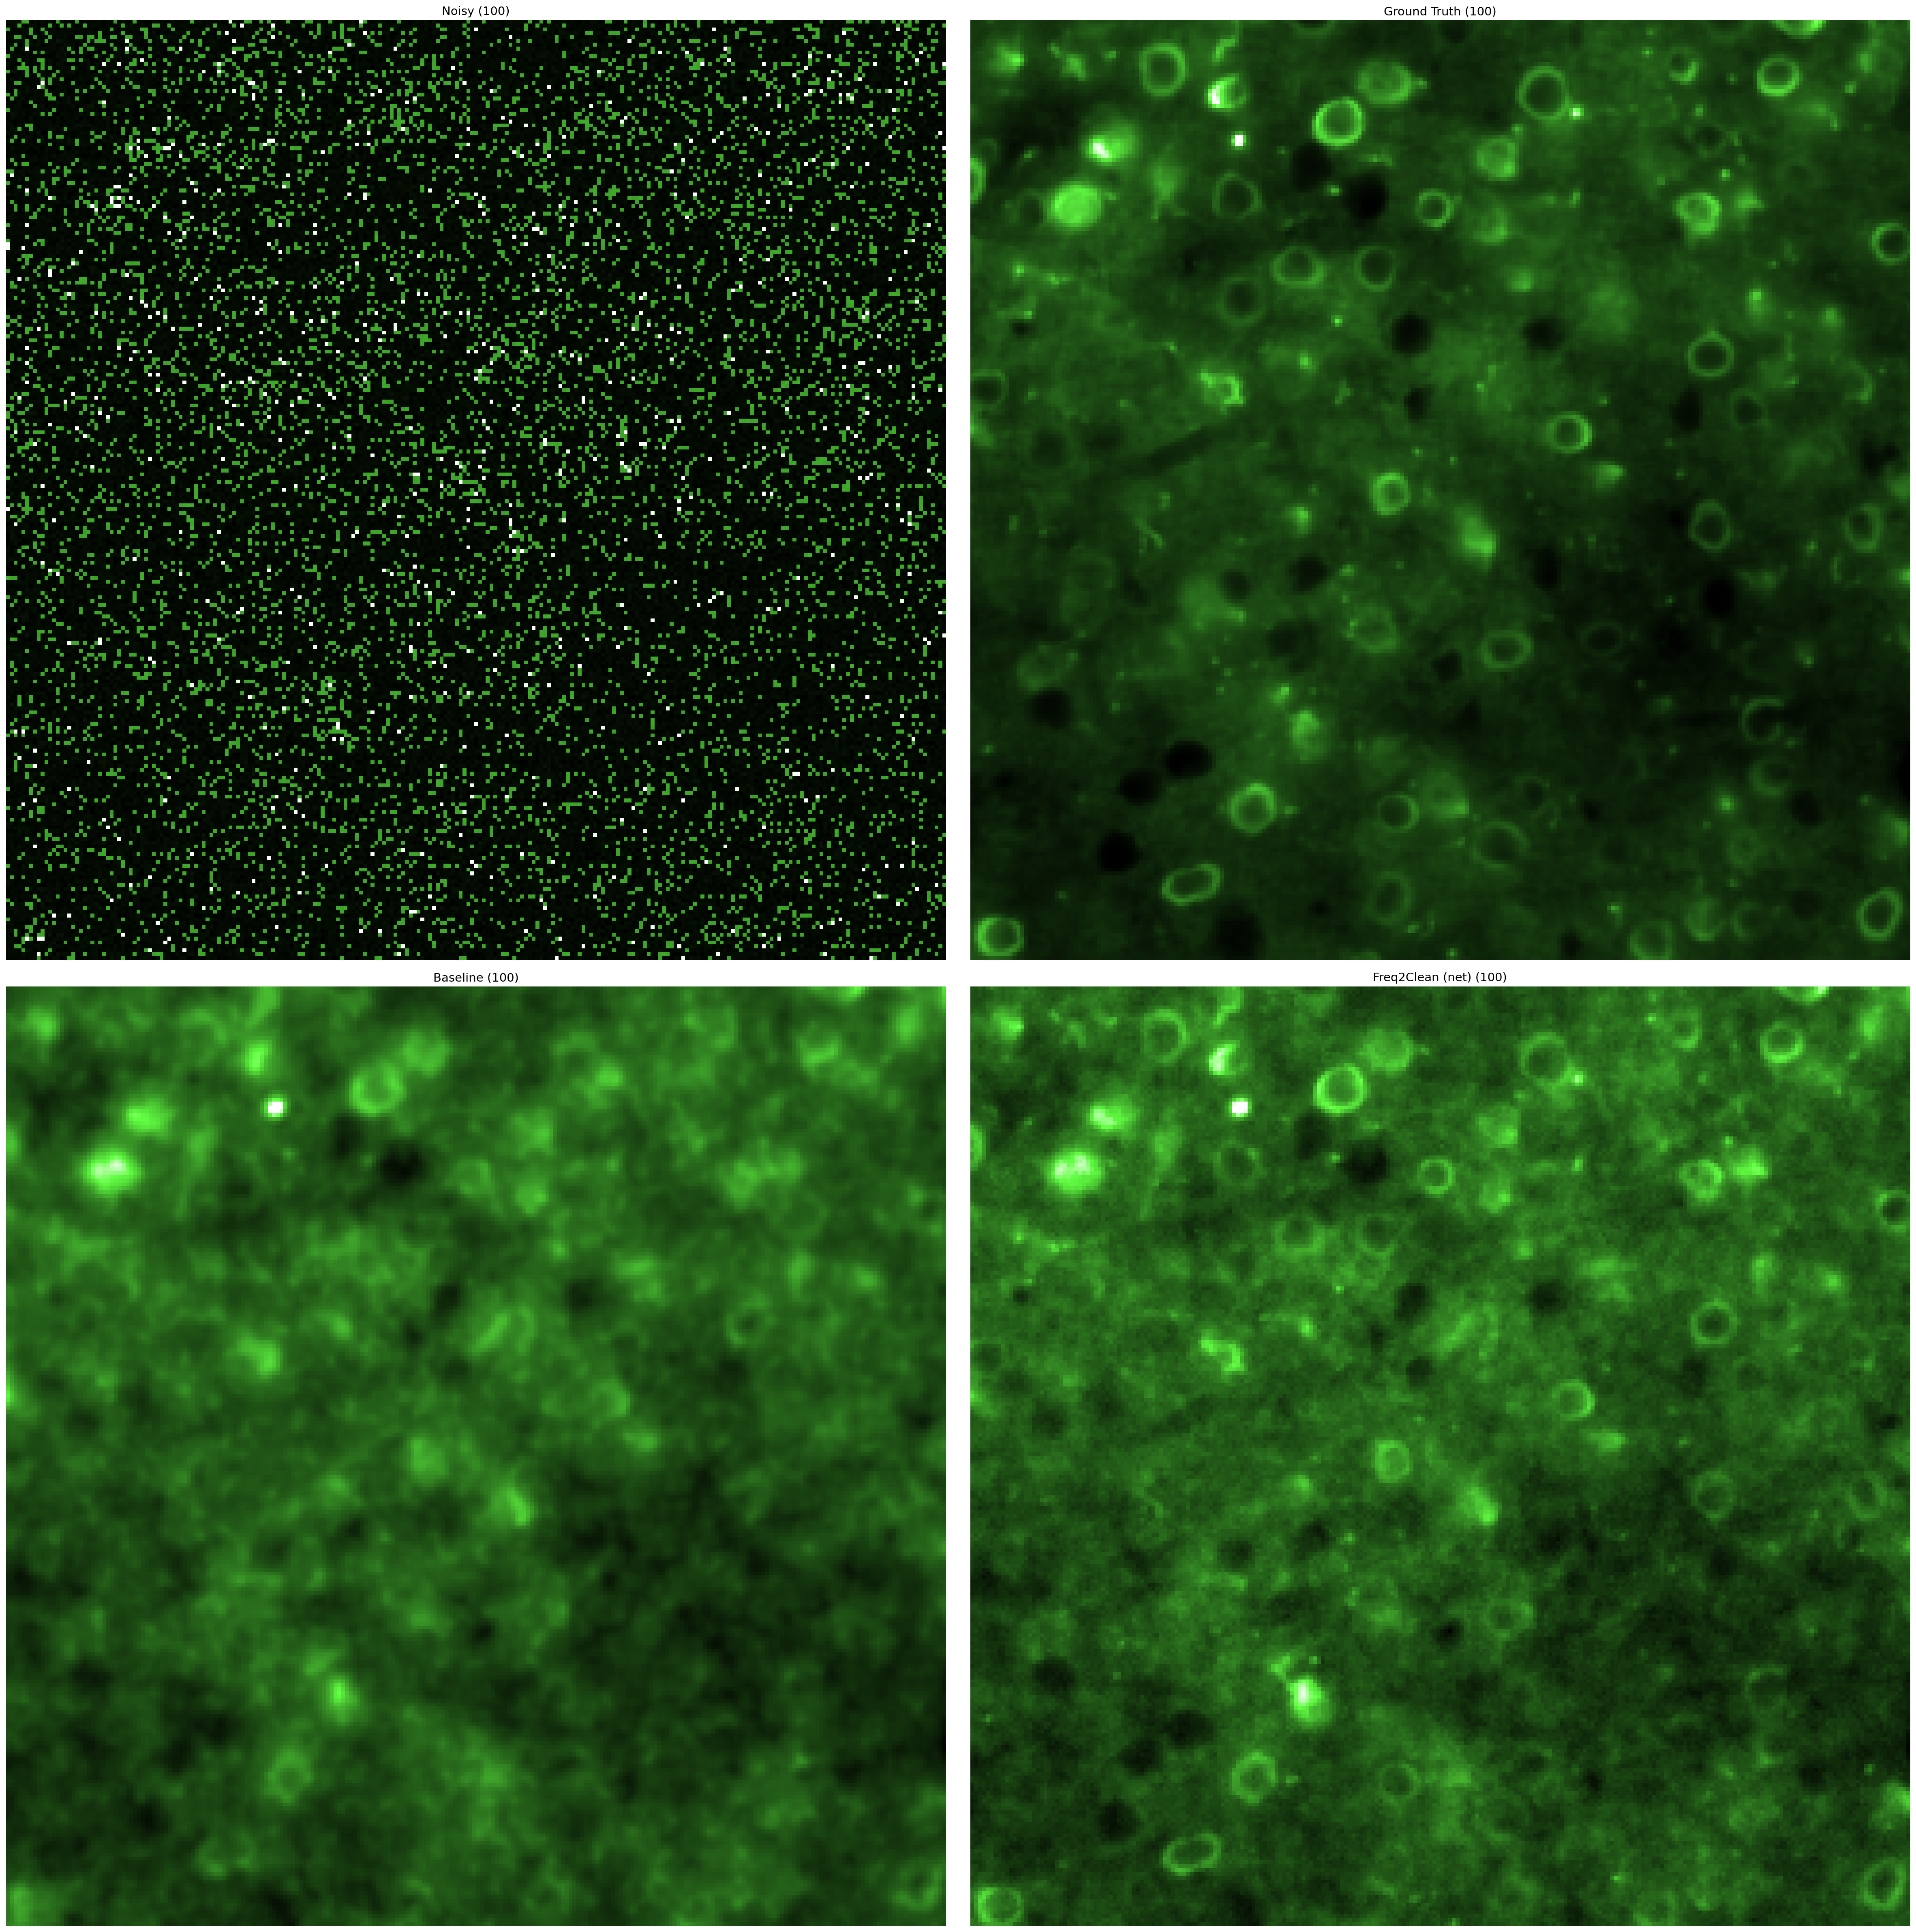

In [4]:
i = 100
imshow(
    {
        f"Noisy ({i})": x.np[i],
        f"Ground Truth ({i})": gt.np[i],
        f"Baseline ({i})": deepcad.np[i],
        # f"Freq2Clean (grid) ({i})": f2c_grid.np[i],
        f"Freq2Clean (net) ({i})": f2c_net.np[i],
    },
    size=16,
    cols=2,
    zoom=2, vrange=(0,1)
)

In [ ]:
deepcad.render(f"deepcad{variant}.mp4", bitrate=6_000)
f2c_grid.render(f"f2c_grid_{method}{variant}.mp4", bitrate=6_000)
f2c_net.render(f"f2c_net_{method}{variant}.mp4", bitrate=6_000)

In [ ]:
Editor().make_green(f"deepcad{variant}.mp4", bitrate=6_000)
Editor().make_green(f"f2c_grid_{method}{variant}.mp4", bitrate=6_000)
Editor().make_green(f"f2c_net_{method}{variant}.mp4", bitrate=6_000)

In [ ]:
Editor().alternate(
    {
        f"DeepCAD-RT ({variant[1:]})": f"deepcad{variant}.mp4",
        f"Freq2Clean (net)": f"f2c_net_{method}{variant}.mp4",
    },
    bitrate=6_000,
    output=f"deepcad_vs_freq2clean_net_{method}{variant}.mp4",
)